In [1]:
import scanpy as sc

# 读取 .h5ad 文件
adata_all = sc.read("/public/users/xueyupeng/VZV/lvzhu/record/adata_all_celltype_50k.h5ad")

In [2]:
markers = ['CD8_112Cd','CD3_113In',  'CD4_115In', 'CD57_139La', 'CD56_141Pr', 
           'IgD_142Nd', 'IFN-a_144Nd', 'CXCL9_146Nd', 'CD86_147Sm','H3K27ac_148Nd', 
           'IL-1b_149Sm', '4E-BP1_150Nd', 'pS6_151Eu','CCR2_152Sm', 'TNF-a_153Eu', 
           'IL-4_154Sm', 'CD14_155Gd', 'CASP-8_156Gd','TCR-gd_158Gd', 'CD38_159Tb', 
           'CD27_160Gd', 'CD123_161Dy','Ki-67_162Dy', 'CXCL10_163Dy', 'Arginase-1_164Dy', 
           'IL-6_165Ho','MCP-1_166Er', 'CD69_167Er', 'STC1_168Er', 'GZMB_169Tm', 
           'CD45RA_170Er','HLA-DR_171Yb', 'IFN-g_172Yb', 'CD11c_173Yb', 'CD19_174Yb',
       'pSTAT1_175Lu', 'pSTAT3_176Yb',  'CD16_209Bi']

IOStream.flush timed out


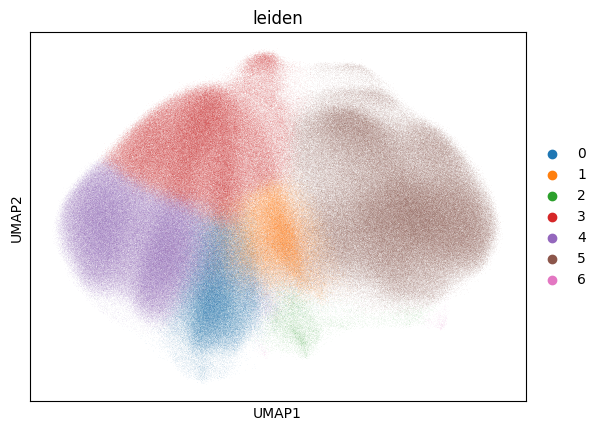

In [4]:
# Filter the AnnData object by specific celltypes  
# 按特定细胞类型过滤 AnnData 对象
celltypes_of_interest = ['CD8T']

adata_filtered = adata_all[adata_all.obs['celltype'].isin(celltypes_of_interest)].copy()

mask = adata_filtered.var_names.isin(markers)

# Perform PCA (if not already performed)
sc.tl.pca(adata_filtered, svd_solver='arpack', n_comps=30,mask_var=mask)

# Compute the neighborhood graph
sc.pp.neighbors(adata_filtered, n_neighbors=10, use_rep='X_pca')

# Perform UMAP (if not already performed)
sc.tl.umap(adata_filtered)

# Perform clustering (e.g., Leiden clustering)
sc.tl.leiden(
    adata_filtered,
    resolution=0.5,
    flavor="igraph",
    n_iterations=2,
    directed=False
)

# You can also visualize the UMAP with Leiden clustering results
sc.pl.umap(adata_filtered, color=['leiden'])

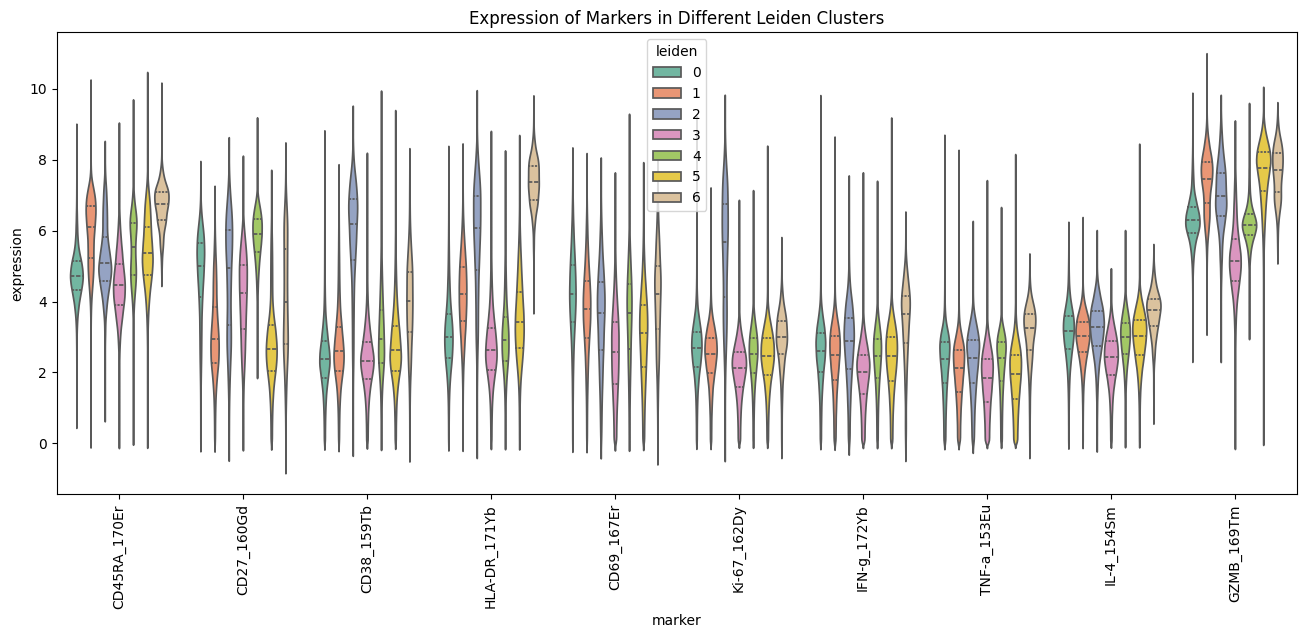

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 选择需要的小提琴图标记物
markers_NK = [
    'CD45RA_170Er',
    'CD27_160Gd',
    'CD38_159Tb',
    'HLA-DR_171Yb',
    'CD69_167Er',
    'Ki-67_162Dy',
    'IFN-g_172Yb',
    'TNF-a_153Eu',
    'IL-4_154Sm',
    'GZMB_169Tm'
]
# 获取标记物的表达数据
data_long = adata_filtered.obs[['leiden']].copy()
for marker in markers_NK:
    data_long[marker] = adata_filtered[:, marker].X.toarray().flatten()  # 获取表达数据并转换为扁平化的数组

# 将数据转换为长格式
data_long = pd.melt(data_long, id_vars=['leiden'], value_vars=markers_NK,
                    var_name='marker', value_name='expression')

# 绘制小提琴图
plt.figure(figsize=(16, 6))
sns.violinplot(x='marker', y='expression', hue='leiden', data=data_long, split=False, inner="quart",
               palette="Set2", dodge=True)
plt.xticks(rotation=90)
plt.title("Expression of Markers in Different Leiden Clusters")
plt.show()


In [6]:
# 统计每个cluster的细胞数
cluster_counts = adata_filtered.obs['leiden'].value_counts()

# 显示结果
print(cluster_counts)

leiden
5    489409
4    337050
3    302741
0    143724
1    117909
2     12741
6       701
Name: count, dtype: int64


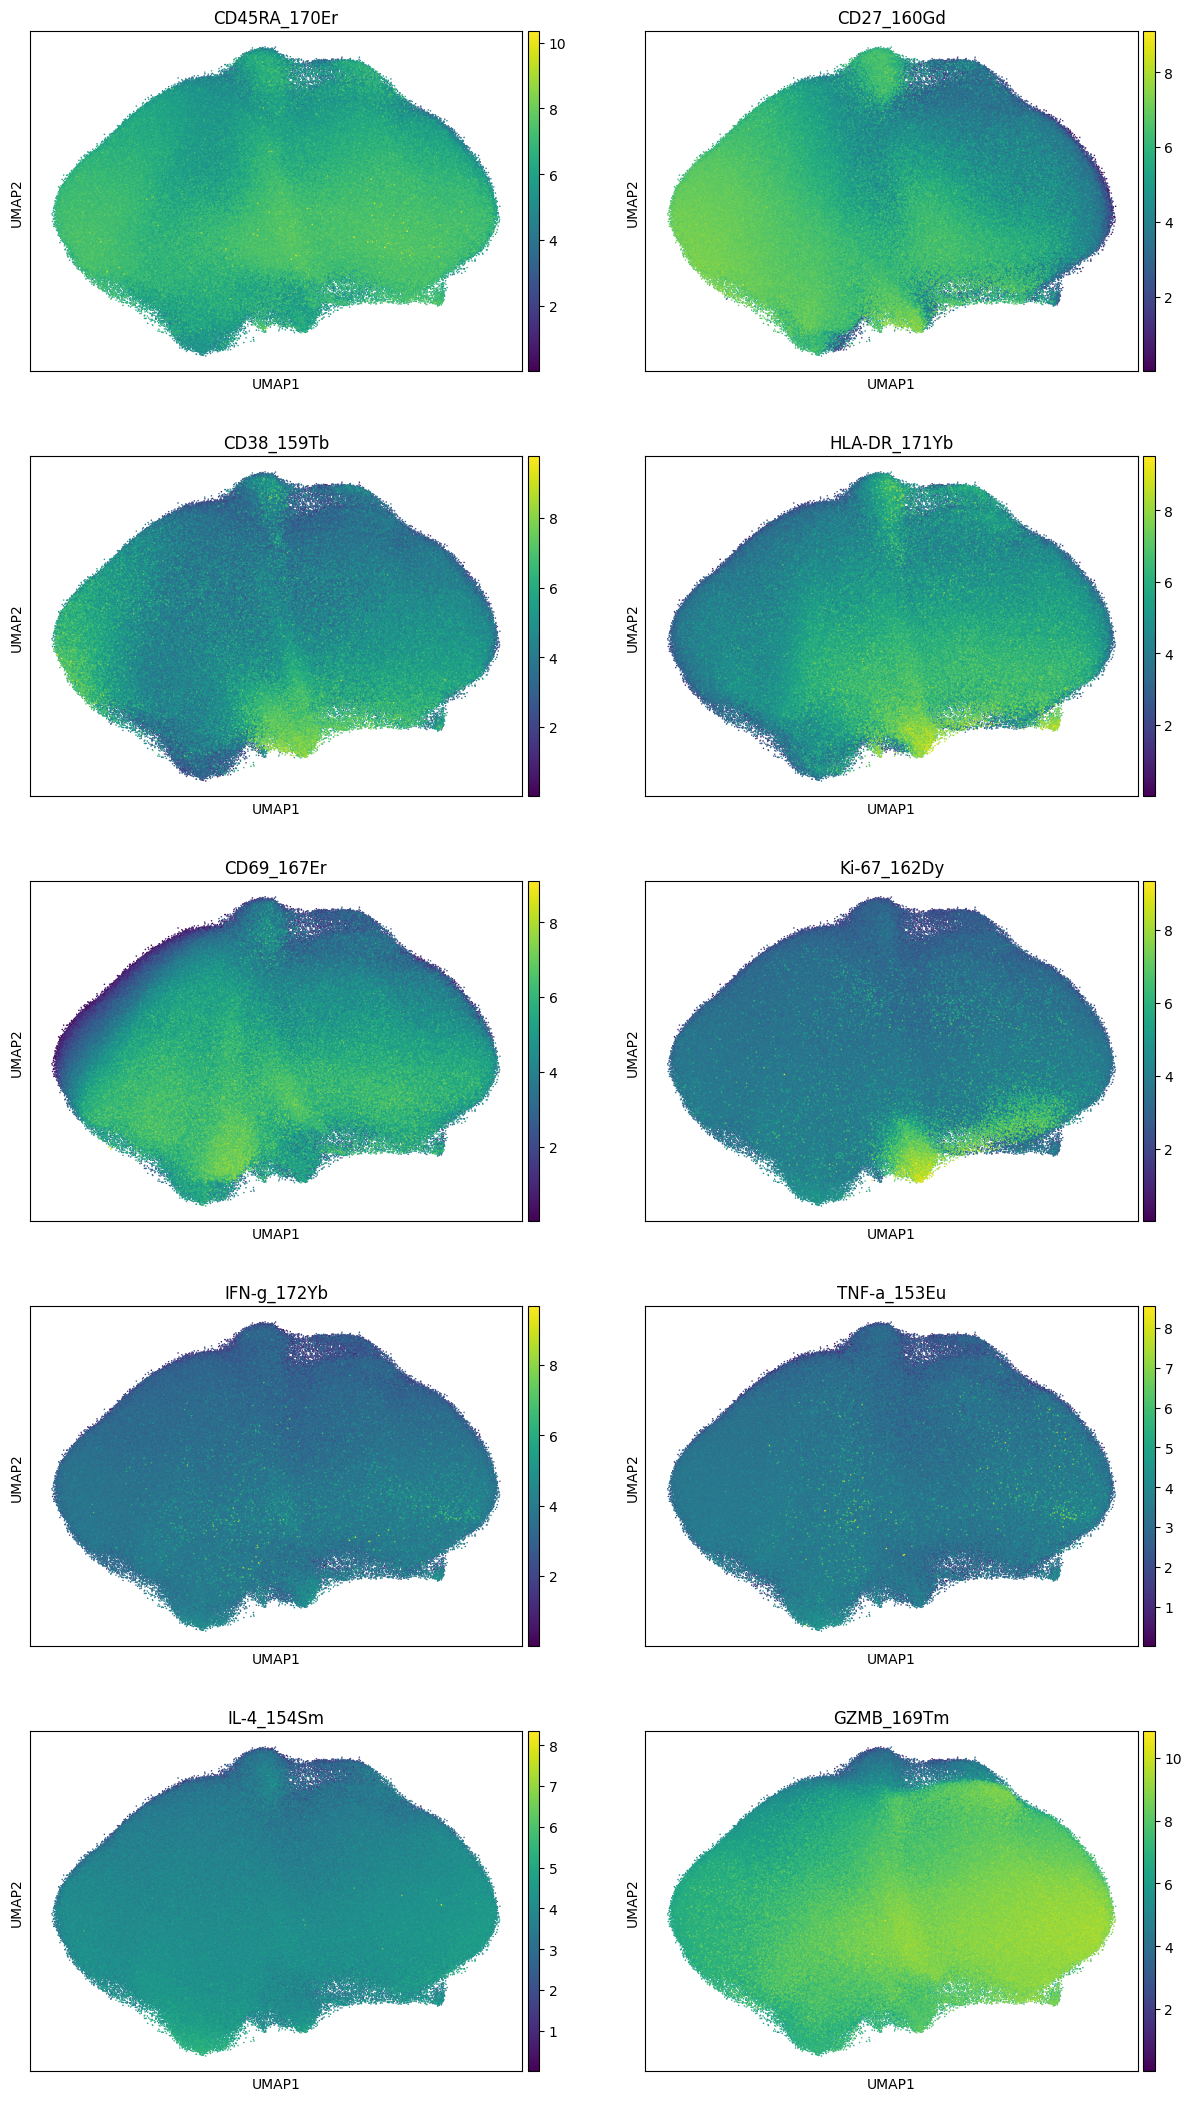

In [7]:
markers_sub =[
    'CD45RA_170Er',
    'CD27_160Gd',
    'CD38_159Tb',
    'HLA-DR_171Yb',
    'CD69_167Er',
    'Ki-67_162Dy',
    'IFN-g_172Yb',
    'TNF-a_153Eu',
    'IL-4_154Sm',
    'GZMB_169Tm'
]

sc.pl.umap(adata_filtered, color=markers_sub, cmap='viridis', ncols=2, size=5)

In [9]:
cluster_anno = {
    "0": "CD8TCM",
    "1": "CD8TEM",
    "2": "CD8TCM_Ki-67+",
    "3": "CD8TEM",
    "4": "CD8TCM",
    "5": "CD8CTL",
    "6":"CD8CTL"
}

In [10]:
adata_filtered.obs["subtype"] = adata_filtered.obs["leiden"].map(cluster_anno)

In [11]:
cell_info_df = pd.DataFrame({
    'cellid': adata_filtered.obs.index,  # 细胞ID
    'sample': adata_filtered.obs['Sample'],  # 样本ID
    'celltype': adata_filtered.obs['celltype'],  # 细胞类型
    'subtype': adata_filtered.obs['subtype'] # 细胞亚型  
})
cell_info_df.head()
cell_info_df.to_csv('/public/users/xueyupeng/VZV/lvzhu/record/subtype_annotations_CD8.csv', index=False)

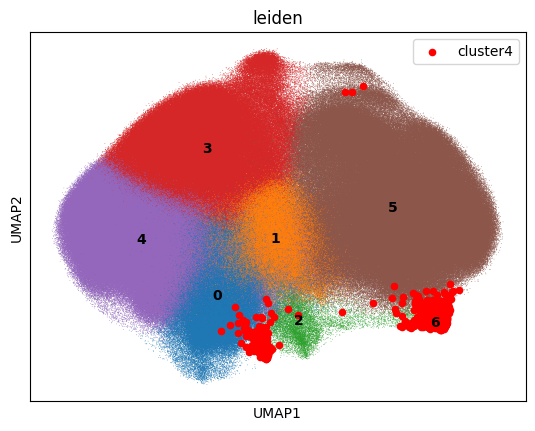

In [8]:
import scanpy as sc
import numpy as np

# 获取 cluster5 的mask
mask = adata_filtered.obs['leiden'] == '6'

# 先画所有点（灰色）
sc.pl.umap(
    adata_filtered,
    color='leiden',
    legend_loc='on data',
    size=1,
    show=False
)

# 在当前图上叠加 cluster5（红色）
import matplotlib.pyplot as plt

umap = adata_filtered.obsm['X_umap']

plt.scatter(
    umap[mask, 0],
    umap[mask, 1],
    c='red',
    s=20,
    label='cluster6'
)

plt.legend()
plt.show()